# Prepare the Dataset

In [1]:
import wfdb
import pandas as pd
import os
import glob

## Explore the Dataset

In [2]:
DATASET_PATH = '..\\data\\mit-bih-arrhythmia-database\\'

In [20]:
sample = 200
record = wfdb.rdrecord(os.path.join(DATASET_PATH, '100'), sampto=sample)
annotation = wfdb.rdann(os.path.join(DATASET_PATH, '100'), 'atr', sampto=sample)

In [21]:
fs = record.fs
print(f'frequency: {fs}')

frequency: 360


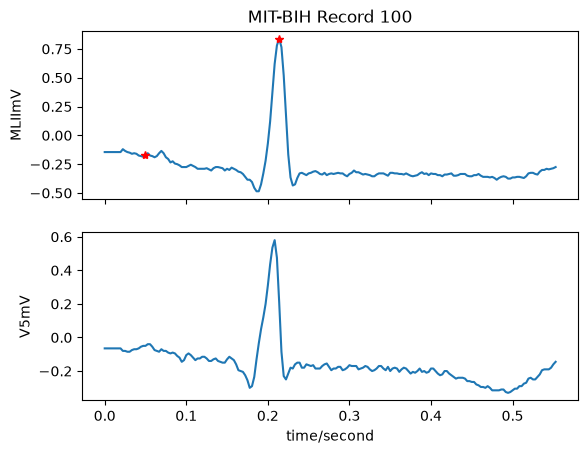

In [22]:
wfdb.plot_wfdb(
    record=record,
    annotation=annotation,
    title='MIT-BIH Record 100'
)

## Select ECGs from MLII channel

beat symbols:
* N -> 0 : Non-ecotic beats (normal beat)
* S -> 1: Supraventricular ectopic beats
* V -> 2: Ventricular ectopic beats*
* F -> 3: Fusion Beats
* Q -> 4: Unknown Beats

In [3]:
files = glob.glob(os.path.join(DATASET_PATH, '*.dat'))
print(f"Found {len(files)} files.")

Found 48 files.


In [4]:
idx = [os.path.split(f)[-1].split('.')[0] for f in files]

In [5]:
signals_df = pd.DataFrame()
beat_indices = dict()
beat_symbols = dict()

for i in idx:
    name = os.path.join(DATASET_PATH, i)

    record = wfdb.rdrecord(name)

    if 'MLII' in record.sig_name:
        signals_df[int(i)] = record.p_signal[:, record.sig_name.index('MLII')]

        annotation = wfdb.rdann(name, 'atr')

        beat_indices[int(i)] = annotation.sample.tolist()

        mapping = {'N': 0, 'S': 1, 'V': 2, 'F': 3}
        beat_symbols[int(i)] = [mapping.get(x, 4) for x in annotation.symbol]

In [7]:
import json

signals_df.to_csv('../data/signals.csv', index=False)

with open("../data/beat_indices.json", "w", encoding="utf-8") as f:
    json.dump(beat_indices, f, ensure_ascii=False, indent=4)

with open("../data/beat_symbols.json", "w", encoding="utf-8") as f:
    json.dump(beat_symbols, f, ensure_ascii=False, indent=4)